## Data Analysis of Ames Iowa Housing Dataset

## Install & Load Libraries

In [2]:
#pip install numpy pandas matplotlib seaborn scikit-learn xgboost optuna shap joblib

In [1]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression, RFE, SelectFromModel
#from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor 
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
import optuna
import joblib
import skops.io as sio

In [2]:
import shap
import xgboost

## Load Dataset

In [3]:
Ames = pd.read_csv('AmesHousing.csv')
Ames.sample(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
270,271,907401090,20,RL,48.0,10635,Pave,NaN,IR2,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,232000
1115,1116,528431060,20,RL,78.0,10206,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,10,2008,WD,Normal,245000
454,455,528175050,120,RL,80.0,10307,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,212500
2040,2041,903475040,50,RM,NaN,12358,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,128500
2188,2189,908228010,40,RL,62.0,10042,Pave,NaN,Reg,Bnk,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,108500


In [159]:
#Ames = pd.read_csv('AmesHousing.csv', header=0, sep=',')
#Ames.sample(5)

## Data Preprocessing & EDA

In [7]:
df = pd.DataFrame(Ames)
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [162]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [163]:
# .nunique is similar to .value_counts except that .value_counts outputs more details and requires iteration through each column
# .nunique prints out number of unique element in each column
a = df.nunique()
a

Order             2930
PID               2930
MS SubClass         16
MS Zoning            7
Lot Frontage       128
                  ... 
Mo Sold             12
Yr Sold              5
Sale Type           10
Sale Condition       6
SalePrice         1032
Length: 82, dtype: int64

In [164]:
# .value_counts() work in iteration only. Iterating through each column. The context here is column index
# .value_counts prints out the count of unique values(ie. element) in each column
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts())
    print('****' * 10)

MS Zoning
RL         2273
RM          462
FV          139
RH           27
C (all)      25
I (all)       2
A (agr)       2
Name: count, dtype: int64
****************************************
Street
Pave    2918
Grvl      12
Name: count, dtype: int64
****************************************
Alley
Grvl    120
Pave     78
Name: count, dtype: int64
****************************************
Lot Shape
Reg    1859
IR1     979
IR2      76
IR3      16
Name: count, dtype: int64
****************************************
Land Contour
Lvl    2633
HLS     120
Bnk     117
Low      60
Name: count, dtype: int64
****************************************
Utilities
AllPub    2927
NoSewr       2
NoSeWa       1
Name: count, dtype: int64
****************************************
Lot Config
Inside     2140
Corner      511
CulDSac     180
FR2          85
FR3          14
Name: count, dtype: int64
****************************************
Land Slope
Gtl    2789
Mod     125
Sev      16
Name: count, dtype: int64
********

**Let's check if our dataset is a classification or regression type**

In [166]:
df['SalePrice'].value_counts()

SalePrice
135000    34
140000    33
130000    29
155000    28
145000    26
          ..
219990     1
159895     1
187687     1
217300     1
150900     1
Name: count, Length: 1032, dtype: int64

**From the output above, we have values that are continous and the least count is 1. It takes a minimum count of 2 to have a classification dataset.**

**Thus, it's a regression dataset.**

In [9]:
df.duplicated().any()

False

In [168]:
df.drop_duplicates()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


**Check for duplicated index**

In [170]:
df.duplicated().any()

False

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [172]:
## Sorting then Filtering (Not the best approach)
#missing_values = df.isnull().sum().sort_values(ascending=True)
#print(missing_values[missing_values > 0])

## Filtering then Sorting (is the best approach)
missing_values = df.isnull().sum()
missing_values_filtered_sorted = missing_values[missing_values > 0].sort_values(ascending=True)
missing_values_filtered_sorted

Electrical           1
Garage Cars          1
BsmtFin SF 1         1
Garage Area          1
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Bsmt Half Bath       2
Bsmt Full Bath       2
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
BsmtFin Type 2      81
Bsmt Exposure       83
Garage Type        157
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Lot Frontage       490
Fireplace Qu      1422
Mas Vnr Type      1775
Fence             2358
Alley             2732
Misc Feature      2824
Pool QC           2917
dtype: int64

In [173]:
percent_missing_values = (missing_values_filtered_sorted / df.shape[0]) *100
percent_missing_values

Electrical         0.034130
Garage Cars        0.034130
BsmtFin SF 1       0.034130
Garage Area        0.034130
BsmtFin SF 2       0.034130
Bsmt Unf SF        0.034130
Total Bsmt SF      0.034130
Bsmt Half Bath     0.068259
Bsmt Full Bath     0.068259
Mas Vnr Area       0.784983
Bsmt Qual          2.730375
Bsmt Cond          2.730375
BsmtFin Type 1     2.730375
BsmtFin Type 2     2.764505
Bsmt Exposure      2.832765
Garage Type        5.358362
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Lot Frontage      16.723549
Fireplace Qu      48.532423
Mas Vnr Type      60.580205
Fence             80.477816
Alley             93.242321
Misc Feature      96.382253
Pool QC           99.556314
dtype: float64

**We will drop features with missing values of 50% and above. Thus, we are dropping 6 features with missing values from 50% and above.** 

**We will also drop the 'Order' and 'PID' columns because they serve no use for Merchine Learning.**

**NOTE:** To create a new dataframe, **always .select_dtypes(include=['int', 'float', 'object']) before you .drop(columns=['SalePrice'])**, and **don't use inplace=True** But if your intention is to modify an existing dataframe (e.g., to drop column(s)), there is **no need to .select_dtypes()**. Use **inplace=True, but do not create an object** for the drop operation (such as assigning it to df). Otherwise, your
print of **df will return 'None'**.

**You CANNOT pass an object and use inplace=True at the same time**

In [176]:
df.drop(columns=['Order', 'PID', 'Fireplace Qu', 'Mas Vnr Type', 'Fence', 'Alley', 'Misc Feature', 'Pool QC'], inplace=True)

In [177]:
df.columns

Index(['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope',
       'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond',
       'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Garage Type',
       'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area',
       'Garage Q

In [178]:
df.shape

(2930, 74)

In [179]:
df.duplicated().any()

False

Note: If you forget to add 'float' to the .select_dtype, you run into error of having incomplete total numeric columns.

In [181]:
#X_numerical_df = df.select_dtypes(include=['int', 'float']).drop(columns='SalePrice')
#print(X_numerical_df.head())

**We Split the dataframe into X and y set**

In [183]:
X_df = df.select_dtypes(['int', 'float', 'object']).drop(columns='SalePrice')
X_df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,62,0,0,0,0,0,5,2010,WD,Normal
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,120,0,0,6,2010,WD,Normal
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,36,0,0,0,0,12500,6,2010,WD,Normal
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,0,4,2010,WD,Normal
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,34,0,0,0,0,0,3,2010,WD,Normal


**Check for Duplicates:**

In [185]:
X_df.duplicated().any()

True

**Drop duplicates in X_df since duplicated() was True:**

**(Dropping the 'SalePrice column revealed that there was duplication in X_df since duplications are based on the entire columns in a row)**

In [187]:
X_df.drop_duplicates(inplace=True)

In [188]:
X_df.duplicated().any()

False

In [189]:
X_df.shape

(2928, 73)

In [190]:
y_df = df['SalePrice']
y_df.head()

0    215000
1    105000
2    172000
3    244000
4    189900
Name: SalePrice, dtype: int64

In [191]:
y_df.shape

(2930,)

**REINDEX y_df since some duplicates were dropped in X_df:**

In [193]:
y_df = y_df.reindex(X_df.index)

In [194]:
y_df.shape

(2928,)

**Split dataframes as part of preparing for Machine Learning- use train_test_split()**

In [196]:
X_train, X_val, y_train, y_val = train_test_split(X_df, y_df, test_size=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

**Confirm Shapes:**

In [198]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(2114, 73)
(440, 73)
(374, 73)
(2114,)
(440,)
(374,)


**Check for duplicates**

In [200]:
print(X_train.duplicated().any())
print(X_val.duplicated().any())
print(X_test.duplicated().any())
print(y_train.duplicated().any())
print(y_val.duplicated().any())
print(y_test.duplicated().any())

False
False
False
True
True
True


**NOTE- It is Normal to have duplicate values in the y set**

**NOTE- IsolationForest(), used for handling outlier, cannot handle NaN values and would return error, thus the need to remove Missing Values(NaN values included) first.**

**Handling Missing values for Numerical and Categorical data of X set- use SimpleImputer()**

* **Numerical columns**

    * We create the train, val, and test sets for Numerical columns

In [205]:
X_train_numeric = X_train.select_dtypes(include=['float','int'])
print(X_train_numeric.head())
X_val_numeric = X_val.select_dtypes(include=['float','int'])
print('*****' * 15)
print(X_val_numeric.head())
X_test_numeric = X_test.select_dtypes(include=['float','int'])
print('*****' * 15)
print(X_test_numeric.head())

      MS SubClass  Lot Frontage  Lot Area  Overall Qual  Overall Cond  \
1495           60          72.0      7200             6             7   
2489           80          88.0      8471             6             7   
358            60           NaN      8803             6             5   
304            50          60.0      7500             4             4   
2928           20          77.0     10010             5             5   

      Year Built  Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  \
1495        1976            2001           0.0         288.0           0.0   
2489        1977            1995          46.0         506.0           0.0   
358         1994            1995           0.0         600.0           0.0   
304         1920            1950           0.0           0.0           0.0   
2928        1974            1975           0.0        1071.0         123.0   

      ...  Garage Area  Wood Deck SF  Open Porch SF  Enclosed Porch  \
1495  ...        440.

* **Categorical columns**

    * We create the train, val, and test sets for Categorical columns

In [207]:
X_train_category = X_train.select_dtypes(include='object')
print(X_train_category.head())
X_val_category = X_val.select_dtypes(include='object')
print('*****' * 15)
print(X_val_category.head())
X_test_category = X_test.select_dtypes(include='object')
print('*****' * 15)
print(X_test_category.head())

     MS Zoning Street Lot Shape Land Contour Utilities Lot Config Land Slope  \
1495        RL   Pave       Reg          Lvl    AllPub     Inside        Gtl   
2489        RL   Pave       IR1          Lvl    AllPub     Corner        Gtl   
358         RL   Pave       IR1          Lvl    AllPub     Inside        Gtl   
304    C (all)   Pave       Reg          Lvl    AllPub     Inside        Gtl   
2928        RL   Pave       Reg          Lvl    AllPub     Inside        Mod   

     Neighborhood Condition 1 Condition 2  ... Electrical Kitchen Qual  \
1495      Edwards        Norm        Norm  ...      SBrkr           TA   
2489       Sawyer        Norm        Norm  ...      SBrkr           TA   
358       Gilbert        Norm        Norm  ...      SBrkr           Gd   
304        IDOTRR        Norm        Norm  ...      FuseA           TA   
2928      Mitchel        Norm        Norm  ...      SBrkr           TA   

     Functional Garage Type Garage Finish Garage Qual Garage Cond Paved Dr

* **Numerical columns**

**Instantiate SimpleImputer() -create object for SimpleImputer()** 

In [209]:
sim_imputer_numeric = SimpleImputer(strategy='median')

# Fit model to data to train data
sim_imputer_numeric.fit(X_train_numeric)

# Transform X_train_numeric with trained model
X_train_numeric_imputed = sim_imputer_numeric.transform(X_train_numeric)

# Transform X_val_numeric with trained model
X_val_numeric_imputed = sim_imputer_numeric.transform(X_val_numeric)

# Transform X_test_numeric with trained model
X_test_numeric_imputed = sim_imputer_numeric.transform(X_test_numeric)

**Convert Imputed objects back to DataFrames**

**(Notice that we passed the original index (generated at train test split) to the converted dataframes, to avoid future mismatch)**
**Otherwise, these new datframes will have their index reset which we don't want.**

In [211]:
X_train_numeric_imputed_df = pd.DataFrame(X_train_numeric_imputed, columns=X_train_numeric.columns, index=X_train.index)
X_val_numeric_imputed_df = pd.DataFrame(X_val_numeric_imputed, columns=X_val_numeric.columns, index=X_val.index)
X_test_numeric_imputed_df = pd.DataFrame(X_test_numeric_imputed, columns=X_test_numeric.columns, index=X_test.index)

print(X_train_numeric_imputed_df.head())
print('*****' * 15)
print(X_val_numeric_imputed_df.head())
print('*****' * 15)
print(X_test_numeric_imputed_df.head())

      MS SubClass  Lot Frontage  Lot Area  Overall Qual  Overall Cond  \
1495         60.0          72.0    7200.0           6.0           7.0   
2489         80.0          88.0    8471.0           6.0           7.0   
358          60.0          68.0    8803.0           6.0           5.0   
304          50.0          60.0    7500.0           4.0           4.0   
2928         20.0          77.0   10010.0           5.0           5.0   

      Year Built  Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  \
1495      1976.0          2001.0           0.0         288.0           0.0   
2489      1977.0          1995.0          46.0         506.0           0.0   
358       1994.0          1995.0           0.0         600.0           0.0   
304       1920.0          1950.0           0.0           0.0           0.0   
2928      1974.0          1975.0           0.0        1071.0         123.0   

      ...  Garage Area  Wood Deck SF  Open Porch SF  Enclosed Porch  \
1495  ...        440.

* **Categorical columns**

**Instantiate SimpleImputer() -create object for SimpleImputer()**

In [213]:
sim_imputer_category = SimpleImputer(strategy='most_frequent')

# Fit model to data to train data
sim_imputer_category.fit(X_train_category)

# Transform X_train_category with trained model
X_train_category_imputed = sim_imputer_category.transform(X_train_category)

# Transform X_val_category with trained model
X_val_category_imputed = sim_imputer_category.transform(X_val_category)

# Transform X_test_category with trained model
X_test_category_imputed = sim_imputer_category.transform(X_test_category)

**Convert Imputed objects back to DataFrames**

**(Notice that we passed the original index (generated at train test split) to the converted dataframes, to avoid future mismatch)**

In [215]:
X_train_category_imputed_df = pd.DataFrame(X_train_category_imputed, columns=X_train_category.columns, index=X_train.index)
X_val_category_imputed_df = pd.DataFrame(X_val_category_imputed, columns=X_val_category.columns, index=X_val.index)
X_test_category_imputed_df = pd.DataFrame(X_test_category_imputed, columns=X_test_category.columns, index=X_test.index)

print(X_train_category_imputed_df.head())
print('*****' * 15)

print(X_val_category_imputed_df.head())
print('*****' * 15)

print(X_test_category_imputed_df.head())

     MS Zoning Street Lot Shape Land Contour Utilities Lot Config Land Slope  \
1495        RL   Pave       Reg          Lvl    AllPub     Inside        Gtl   
2489        RL   Pave       IR1          Lvl    AllPub     Corner        Gtl   
358         RL   Pave       IR1          Lvl    AllPub     Inside        Gtl   
304    C (all)   Pave       Reg          Lvl    AllPub     Inside        Gtl   
2928        RL   Pave       Reg          Lvl    AllPub     Inside        Mod   

     Neighborhood Condition 1 Condition 2  ... Electrical Kitchen Qual  \
1495      Edwards        Norm        Norm  ...      SBrkr           TA   
2489       Sawyer        Norm        Norm  ...      SBrkr           TA   
358       Gilbert        Norm        Norm  ...      SBrkr           Gd   
304        IDOTRR        Norm        Norm  ...      FuseA           TA   
2928      Mitchel        Norm        Norm  ...      SBrkr           TA   

     Functional Garage Type Garage Finish Garage Qual Garage Cond Paved Dr

**Check shapes to see they are still in line with X_train, X_val, and X_test**

In [217]:
print(X_train_numeric_imputed_df.shape)
print(X_train_category_imputed_df.shape)
print(X_val_numeric_imputed_df.shape)
print(X_val_category_imputed_df.shape)
print(X_test_numeric_imputed_df.shape)
print(X_test_category_imputed_df.shape)

(2114, 36)
(2114, 37)
(440, 36)
(440, 37)
(374, 36)
(374, 37)


**Check that there are no duplicates:**

In [219]:
print(X_train_numeric_imputed_df.duplicated().any())
print(X_train_category_imputed_df.duplicated().any())
print(X_val_numeric_imputed_df.duplicated().any())
print(X_val_category_imputed_df.duplicated().any())
print(X_test_numeric_imputed_df.duplicated().any())
print(X_test_category_imputed_df.duplicated().any())

True
True
False
True
False
True


**Duplicate=True implies that the Imputation process led to the duplications.**

**We will leave this duplicates as they are LEGITIMATE. Removing it will affect the performance and validity of our model**

#### Update:
* **X_train_numeric**
* **X_train_category**
* **X_val_numeric**
* **X_val_category**
* **X_test_numeric**
* **X_test_category**

In [222]:
X_train_numeric = X_train_numeric_imputed_df
X_train_category = X_train_category_imputed_df
X_val_numeric = X_val_numeric_imputed_df
X_val_category = X_val_category_imputed_df
X_test_numeric = X_test_numeric_imputed_df
X_test_category = X_test_category_imputed_df

**Handling Outliers for Numerical data- Use Interquantile Range Method**

* **Numerical columns only for train, val, and test sets of X**

**Visualizing Outliers of all Features with Box Plot**- **Before Handling Outliers**

* **For X_train**

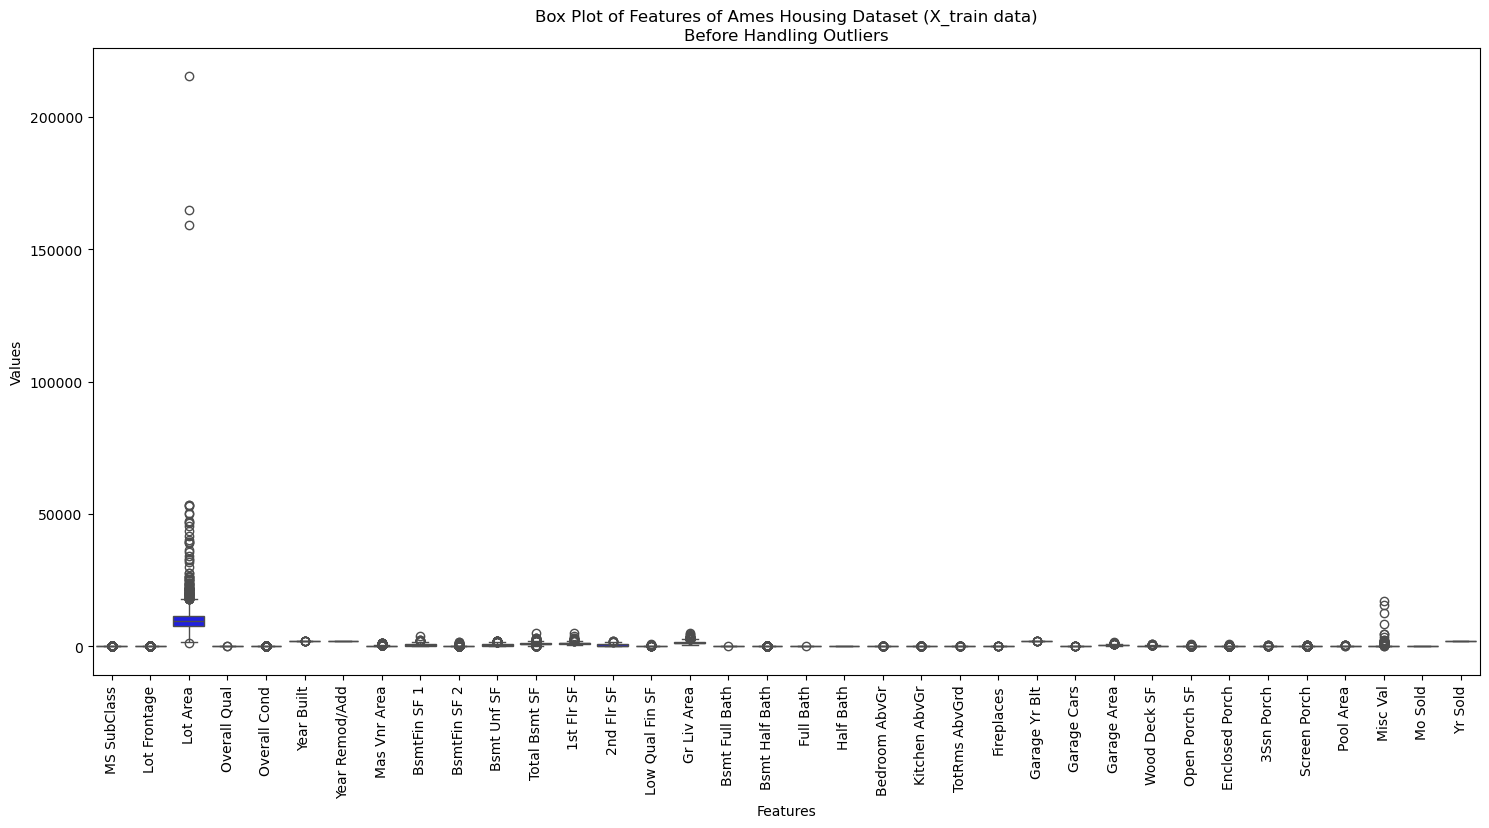

In [226]:
# Melt DataFrame
X_train_numeric_melted = pd.melt(X_train_numeric)

plt.figure(figsize=(15, 8)) 
sns.boxplot(data=X_train_numeric_melted, x='variable', y='value', color='blue')
plt.xlabel('Features')
plt.ylabel('Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.title('Box Plot of Features of Ames Housing Dataset (X_train data)\nBefore Handling Outliers')
plt.show()

* **For X_val**

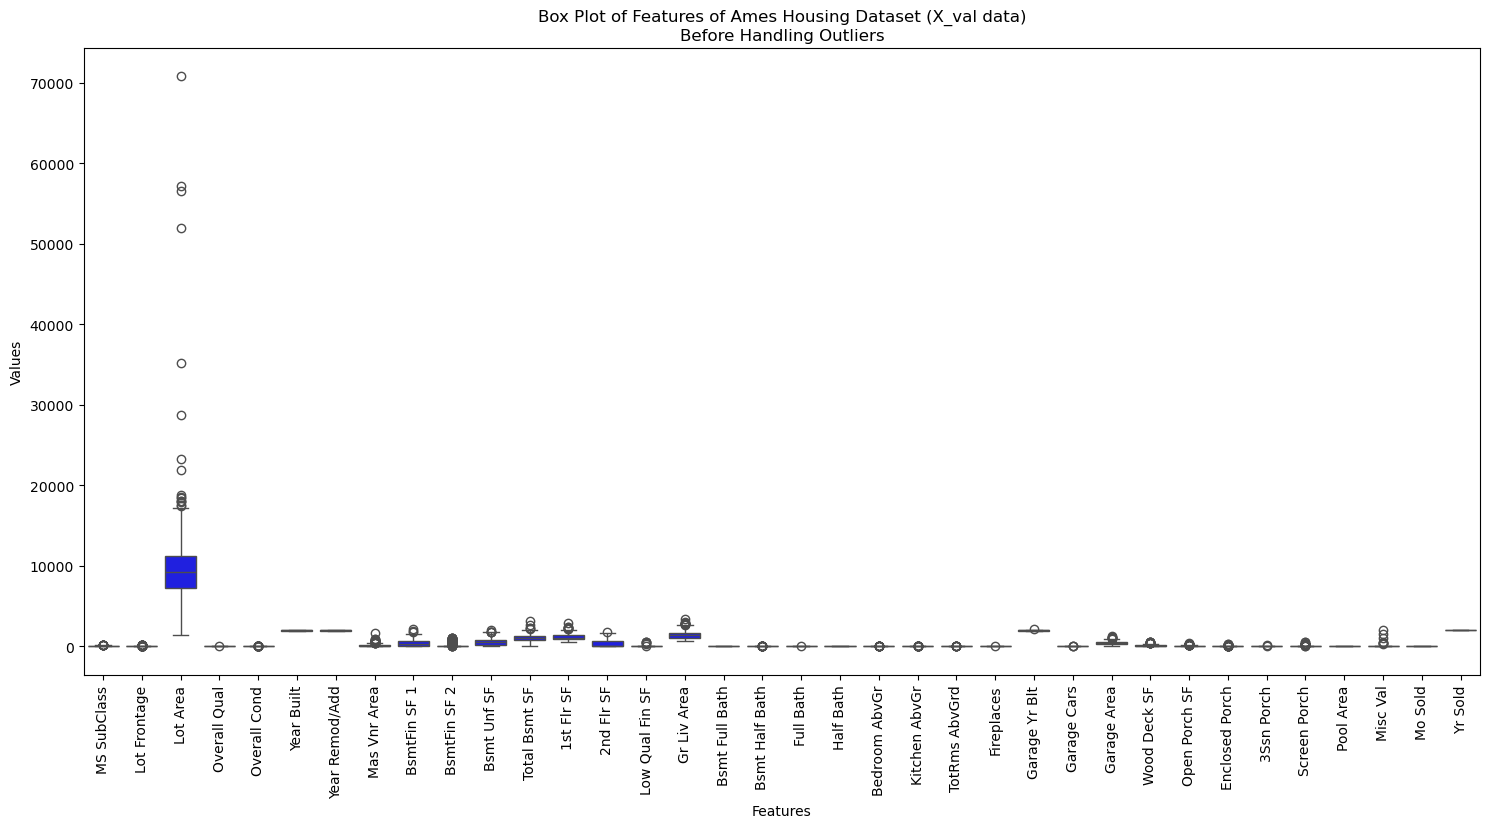

In [228]:
# Melt DataFrame
X_val_numeric_melted = pd.melt(X_val_numeric)

plt.figure(figsize=(15, 8)) 
sns.boxplot(data=X_val_numeric_melted, x='variable', y='value', color='blue')
plt.xlabel('Features')
plt.ylabel('Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.title('Box Plot of Features of Ames Housing Dataset (X_val data)\nBefore Handling Outliers')
plt.show()

* **For X_test**

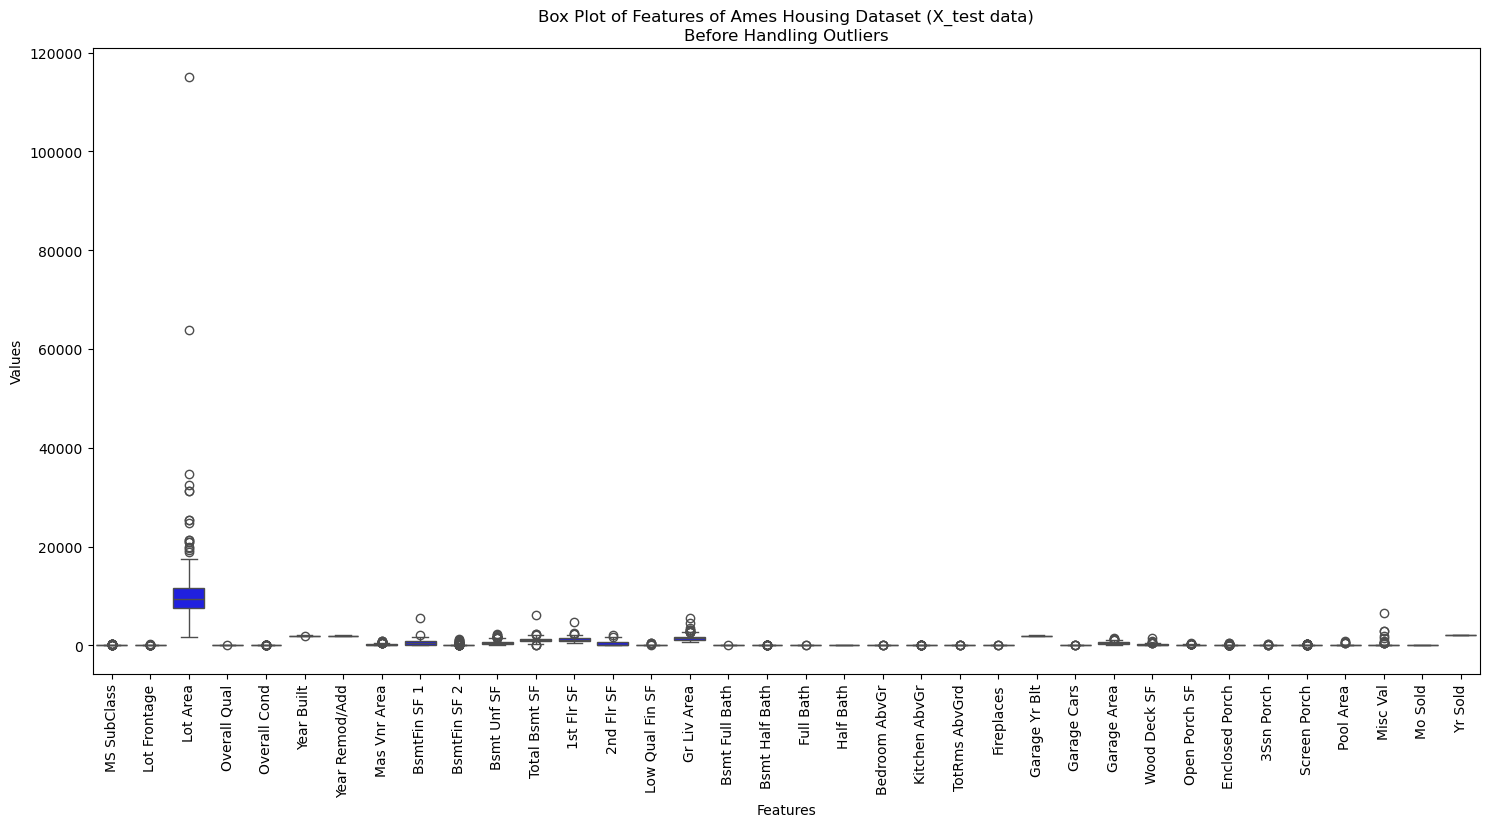

In [230]:
# Melt DataFrame
X_test_numeric_melted = pd.melt(X_test_numeric)

plt.figure(figsize=(15, 8)) 
sns.boxplot(data=X_test_numeric_melted, x='variable', y='value', color='blue')
plt.xlabel('Features')
plt.ylabel('Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.title('Box Plot of Features of Ames Housing Dataset (X_test data)\nBefore Handling Outliers')
plt.show()

**Handling Outliers using Interquantile Range Method on 'any' of the Feature columns (using any(axis=1))**

**IsolationForest() did not significantly remove the outliers**

* **On  X_train_numeric**

In [233]:
Q1 = X_train_numeric.quantile(0.25)
Q3 = X_train_numeric.quantile(0.75)
IQR = Q3 - Q1
# Removing outliers
X_train_numeric_inliers_df = X_train_numeric[~((X_train_numeric < (Q1 - 1.5 * IQR)) | (X_train_numeric > (Q3 + 1.5 *IQR))).any(axis=1)]
print(X_train_numeric_inliers_df.shape)
print(X_train_numeric_inliers_df.isnull().sum())
print(X_train_numeric_inliers_df.head())

(805, 36)
MS SubClass        0
Lot Frontage       0
Lot Area           0
Overall Qual       0
Overall Cond       0
Year Built         0
Year Remod/Add     0
Mas Vnr Area       0
BsmtFin SF 1       0
BsmtFin SF 2       0
Bsmt Unf SF        0
Total Bsmt SF      0
1st Flr SF         0
2nd Flr SF         0
Low Qual Fin SF    0
Gr Liv Area        0
Bsmt Full Bath     0
Bsmt Half Bath     0
Full Bath          0
Half Bath          0
Bedroom AbvGr      0
Kitchen AbvGr      0
TotRms AbvGrd      0
Fireplaces         0
Garage Yr Blt      0
Garage Cars        0
Garage Area        0
Wood Deck SF       0
Open Porch SF      0
Enclosed Porch     0
3Ssn Porch         0
Screen Porch       0
Pool Area          0
Misc Val           0
Mo Sold            0
Yr Sold            0
dtype: int64
      MS SubClass  Lot Frontage  Lot Area  Overall Qual  Overall Cond  \
1495         60.0          72.0    7200.0           6.0           7.0   
2489         80.0          88.0    8471.0           6.0           7.0   
35

* **On X_val_numeric**

In [235]:
Q1 = X_val_numeric.quantile(0.25)
Q3 = X_val_numeric.quantile(0.75)
IQR = Q3 - Q1
# Removing outliers
X_val_numeric_inliers_df = (X_val_numeric[~((X_val_numeric < (Q1 - 1.5 * IQR)) | (X_val_numeric > (Q3 + 1.5 *IQR))).any(axis=1)])
print(X_val_numeric_inliers_df.shape)
print(X_val_numeric_inliers_df.isnull().sum())
print(X_val_numeric_inliers_df.head())

(166, 36)
MS SubClass        0
Lot Frontage       0
Lot Area           0
Overall Qual       0
Overall Cond       0
Year Built         0
Year Remod/Add     0
Mas Vnr Area       0
BsmtFin SF 1       0
BsmtFin SF 2       0
Bsmt Unf SF        0
Total Bsmt SF      0
1st Flr SF         0
2nd Flr SF         0
Low Qual Fin SF    0
Gr Liv Area        0
Bsmt Full Bath     0
Bsmt Half Bath     0
Full Bath          0
Half Bath          0
Bedroom AbvGr      0
Kitchen AbvGr      0
TotRms AbvGrd      0
Fireplaces         0
Garage Yr Blt      0
Garage Cars        0
Garage Area        0
Wood Deck SF       0
Open Porch SF      0
Enclosed Porch     0
3Ssn Porch         0
Screen Porch       0
Pool Area          0
Misc Val           0
Mo Sold            0
Yr Sold            0
dtype: int64
      MS SubClass  Lot Frontage  Lot Area  Overall Qual  Overall Cond  \
2390         60.0          82.0    9942.0           9.0           5.0   
1731         60.0          62.0    8857.0           6.0           5.0   
11

* **On  X_test_numeric**

In [237]:
Q1 = X_test_numeric.quantile(0.25)
Q3 = X_test_numeric.quantile(0.75)
IQR = Q3 - Q1
# Removing outliers
X_test_numeric_inliers_df = (X_test_numeric[~((X_test_numeric < (Q1 - 1.5 * IQR)) | (X_test_numeric > (Q3 + 1.5 *IQR))).any(axis=1)])
print(X_test_numeric_inliers_df.shape)
print(X_test_numeric_inliers_df.isnull().sum())
print(X_test_numeric_inliers_df.head())

(143, 36)
MS SubClass        0
Lot Frontage       0
Lot Area           0
Overall Qual       0
Overall Cond       0
Year Built         0
Year Remod/Add     0
Mas Vnr Area       0
BsmtFin SF 1       0
BsmtFin SF 2       0
Bsmt Unf SF        0
Total Bsmt SF      0
1st Flr SF         0
2nd Flr SF         0
Low Qual Fin SF    0
Gr Liv Area        0
Bsmt Full Bath     0
Bsmt Half Bath     0
Full Bath          0
Half Bath          0
Bedroom AbvGr      0
Kitchen AbvGr      0
TotRms AbvGrd      0
Fireplaces         0
Garage Yr Blt      0
Garage Cars        0
Garage Area        0
Wood Deck SF       0
Open Porch SF      0
Enclosed Porch     0
3Ssn Porch         0
Screen Porch       0
Pool Area          0
Misc Val           0
Mo Sold            0
Yr Sold            0
dtype: int64
      MS SubClass  Lot Frontage  Lot Area  Overall Qual  Overall Cond  \
1463         60.0          65.0    8158.0           7.0           5.0   
2417         60.0          96.0   11631.0           8.0           5.0   
27

**Filter out outliers from:**

* **X_train_category**

* **X_val_category**

* **X_test_category**

* **y_train**

* **y_val**

* **y_test**

**by using REINDEX Method and the index of the inliers.**

* **X_train_category**

In [240]:
X_train_category_inliers_df = X_train_category.reindex(X_train_numeric_inliers_df.index)

print(X_train_category_inliers_df.shape)

print(X_train_category_inliers_df.isnull().sum())

print(X_train_category_inliers_df.head())

(805, 37)
MS Zoning         0
Street            0
Lot Shape         0
Land Contour      0
Utilities         0
Lot Config        0
Land Slope        0
Neighborhood      0
Condition 1       0
Condition 2       0
Bldg Type         0
House Style       0
Roof Style        0
Roof Matl         0
Exterior 1st      0
Exterior 2nd      0
Exter Qual        0
Exter Cond        0
Foundation        0
Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     0
BsmtFin Type 1    0
BsmtFin Type 2    0
Heating           0
Heating QC        0
Central Air       0
Electrical        0
Kitchen Qual      0
Functional        0
Garage Type       0
Garage Finish     0
Garage Qual       0
Garage Cond       0
Paved Drive       0
Sale Type         0
Sale Condition    0
dtype: int64
     MS Zoning Street Lot Shape Land Contour Utilities Lot Config Land Slope  \
1495        RL   Pave       Reg          Lvl    AllPub     Inside        Gtl   
2489        RL   Pave       IR1          Lvl    AllPub     Corner        Gtl 

* **X_val_category**

In [242]:
X_val_category_inliers_df = X_val_category.reindex(X_val_numeric_inliers_df.index)

print(X_val_category_inliers_df.shape)

print(X_val_category_inliers_df.isnull().sum())

print(X_val_category_inliers_df.head())

(166, 37)
MS Zoning         0
Street            0
Lot Shape         0
Land Contour      0
Utilities         0
Lot Config        0
Land Slope        0
Neighborhood      0
Condition 1       0
Condition 2       0
Bldg Type         0
House Style       0
Roof Style        0
Roof Matl         0
Exterior 1st      0
Exterior 2nd      0
Exter Qual        0
Exter Cond        0
Foundation        0
Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     0
BsmtFin Type 1    0
BsmtFin Type 2    0
Heating           0
Heating QC        0
Central Air       0
Electrical        0
Kitchen Qual      0
Functional        0
Garage Type       0
Garage Finish     0
Garage Qual       0
Garage Cond       0
Paved Drive       0
Sale Type         0
Sale Condition    0
dtype: int64
     MS Zoning Street Lot Shape Land Contour Utilities Lot Config Land Slope  \
2390        RL   Pave       IR1          Lvl    AllPub     Inside        Gtl   
1731        RL   Pave       IR1          Lvl    AllPub     Inside        Gtl 

* **X_test_category**

In [244]:
X_test_category_inliers_df = X_test_category.reindex(X_test_numeric_inliers_df.index)

print(X_test_category_inliers_df.shape)

print(X_test_category_inliers_df.isnull().sum())

print(X_test_category_inliers_df.head())

(143, 37)
MS Zoning         0
Street            0
Lot Shape         0
Land Contour      0
Utilities         0
Lot Config        0
Land Slope        0
Neighborhood      0
Condition 1       0
Condition 2       0
Bldg Type         0
House Style       0
Roof Style        0
Roof Matl         0
Exterior 1st      0
Exterior 2nd      0
Exter Qual        0
Exter Cond        0
Foundation        0
Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     0
BsmtFin Type 1    0
BsmtFin Type 2    0
Heating           0
Heating QC        0
Central Air       0
Electrical        0
Kitchen Qual      0
Functional        0
Garage Type       0
Garage Finish     0
Garage Qual       0
Garage Cond       0
Paved Drive       0
Sale Type         0
Sale Condition    0
dtype: int64
     MS Zoning Street Lot Shape Land Contour Utilities Lot Config Land Slope  \
1463        RL   Pave       Reg          Lvl    AllPub     Inside        Gtl   
2417        RL   Pave       IR1          Lvl    AllPub     Corner        Gtl 

* **y_train**

In [246]:
y_train_inliers_df = y_train.reindex(X_train_numeric_inliers_df.index)
print(y_train_inliers_df.shape)
print(y_train_inliers_df.isnull().sum())
print(y_train_inliers_df.head())

(805,)
0
1495    160500
2489    151000
358     181316
2046    126000
299     162500
Name: SalePrice, dtype: int64


* **y_val**

In [248]:
y_val_inliers_df = y_val.reindex(X_val_numeric_inliers_df.index)
print(y_val_inliers_df.shape)
print(y_val_inliers_df.isnull().sum())
print(y_val_inliers_df.head())

(166,)
0
2390    338500
1731    171925
1100    250000
1192    141000
1505    120000
Name: SalePrice, dtype: int64


* **y_test**

In [250]:
y_test_inliers_df = y_test.reindex(X_test_numeric_inliers_df.index)
print(y_test_inliers_df.shape)
print(y_test_inliers_df.isnull().sum())
print(y_test_inliers_df.head())

(143,)
0
1463    224900
2417    258000
2757    233555
1850    204000
464     184000
Name: SalePrice, dtype: int64


**Update:**

* **X_train**

* **X_val**

* **X_test**

* **y_train**

* **y_val**

* **y_test**

**First, we should concat numeric and category**

In [253]:
X_train = pd.concat([X_train_numeric_inliers_df, X_train_category_inliers_df], axis=1)
X_train.head()

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Electrical,Kitchen Qual,Functional,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
1495,60.0,72.0,7200.0,6.0,7.0,1976.0,2001.0,0.0,288.0,0.0,...,SBrkr,TA,Typ,Attchd,Fin,TA,TA,Y,WD,Normal
2489,80.0,88.0,8471.0,6.0,7.0,1977.0,1995.0,46.0,506.0,0.0,...,SBrkr,TA,Typ,Attchd,Unf,TA,TA,Y,WD,Normal
358,60.0,68.0,8803.0,6.0,5.0,1994.0,1995.0,0.0,600.0,0.0,...,SBrkr,Gd,Typ,Attchd,Fin,TA,TA,Y,WD,Normal
2046,50.0,60.0,8160.0,5.0,6.0,1940.0,1950.0,0.0,312.0,0.0,...,FuseF,TA,Typ,Detchd,Unf,TA,TA,P,WD,AdjLand
299,120.0,35.0,3907.0,8.0,5.0,1989.0,1989.0,0.0,76.0,0.0,...,SBrkr,Gd,Typ,Attchd,Unf,TA,TA,Y,WD,Normal


In [254]:
X_val = pd.concat([X_val_numeric_inliers_df, X_val_category_inliers_df], axis=1)
X_val.head()

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Electrical,Kitchen Qual,Functional,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
2390,60.0,82.0,9942.0,9.0,5.0,2005.0,2006.0,385.0,1290.0,0.0,...,SBrkr,Ex,Typ,Attchd,RFn,TA,TA,Y,New,Partial
1731,60.0,62.0,8857.0,6.0,5.0,2006.0,2006.0,0.0,0.0,0.0,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,New,Partial
1100,60.0,84.0,14260.0,8.0,5.0,2000.0,2000.0,350.0,655.0,0.0,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
1192,60.0,73.0,8814.0,5.0,6.0,1968.0,1968.0,0.0,732.0,0.0,...,SBrkr,TA,Typ,Attchd,Unf,TA,TA,Y,WD,Normal
1505,50.0,60.0,12180.0,5.0,7.0,1938.0,2007.0,0.0,0.0,0.0,...,FuseF,Ex,Typ,Attchd,Unf,TA,TA,N,WD,Family


In [255]:
X_test = pd.concat([X_test_numeric_inliers_df, X_test_category_inliers_df], axis=1)
X_test.head()

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Electrical,Kitchen Qual,Functional,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
1463,60.0,65.0,8158.0,7.0,5.0,2003.0,2003.0,252.0,550.0,0.0,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
2417,60.0,96.0,11631.0,8.0,5.0,2004.0,2005.0,236.0,0.0,0.0,...,SBrkr,Gd,Typ,BuiltIn,Fin,TA,TA,Y,New,Partial
2757,20.0,90.0,13377.0,6.0,5.0,2006.0,2006.0,0.0,1576.0,0.0,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,New,Partial
1850,20.0,73.0,7321.0,7.0,5.0,1999.0,2000.0,0.0,0.0,0.0,...,SBrkr,Gd,Typ,Detchd,Unf,TA,TA,Y,COD,Normal
464,60.0,63.0,10928.0,7.0,5.0,2005.0,2005.0,0.0,0.0,0.0,...,SBrkr,Gd,Typ,Attchd,Fin,TA,TA,Y,WD,Normal


In [256]:
y_train = y_train_inliers_df
y_train.head()

1495    160500
2489    151000
358     181316
2046    126000
299     162500
Name: SalePrice, dtype: int64

In [257]:
y_val = y_val_inliers_df
y_val.head()

2390    338500
1731    171925
1100    250000
1192    141000
1505    120000
Name: SalePrice, dtype: int64

In [258]:
y_test = y_test_inliers_df
y_test.head()

1463    224900
2417    258000
2757    233555
1850    204000
464     184000
Name: SalePrice, dtype: int64

* **Check shape**

In [260]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(805, 73)
(166, 73)
(143, 73)
(805,)
(166,)
(143,)


**Box Plot Visualization After Handling Outliers:**

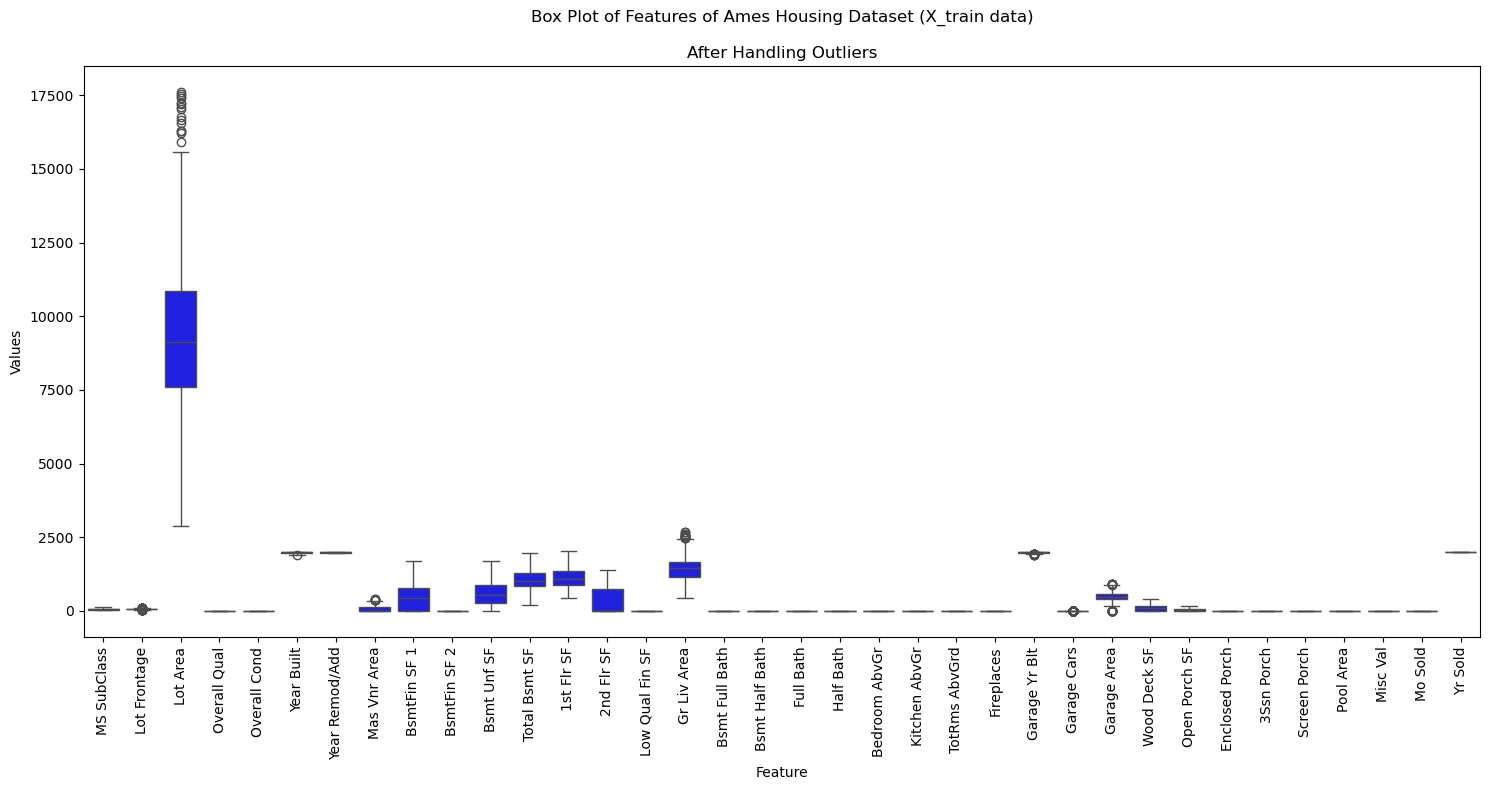

In [262]:
# Melt DataFrame
X_train_numeric_melted = pd.melt(X_train_numeric_inliers_df)

plt.figure(figsize=(15,8))
sns.boxplot(data=X_train_numeric_melted, x='variable', y='value', color='blue')
plt.xticks(rotation=90)
plt.xlabel('Feature')
plt.ylabel('Values')
plt.title('Box Plot of Features of Ames Housing Dataset (X_train data)\n\nAfter Handling Outliers')
plt.tight_layout()
plt.show()

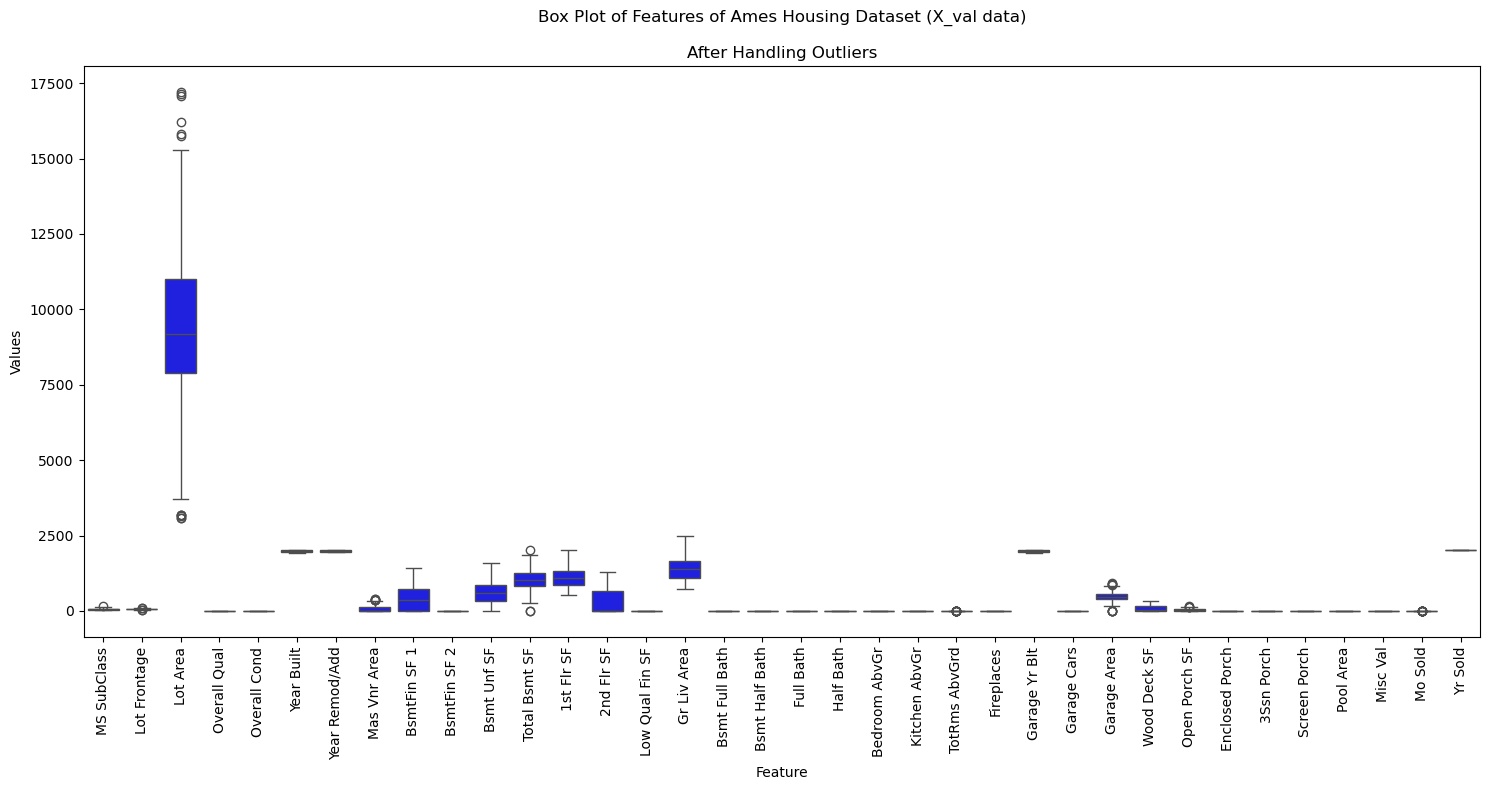

In [263]:
# Melt DataFrame
X_val_numeric_melted = pd.melt(X_val_numeric_inliers_df)

plt.figure(figsize=(15,8))
sns.boxplot(data=X_val_numeric_melted, x='variable', y='value', color='blue')
plt.xticks(rotation=90)
plt.xlabel('Feature')
plt.ylabel('Values')
plt.title('Box Plot of Features of Ames Housing Dataset (X_val data)\n\nAfter Handling Outliers')
plt.tight_layout()
plt.show()

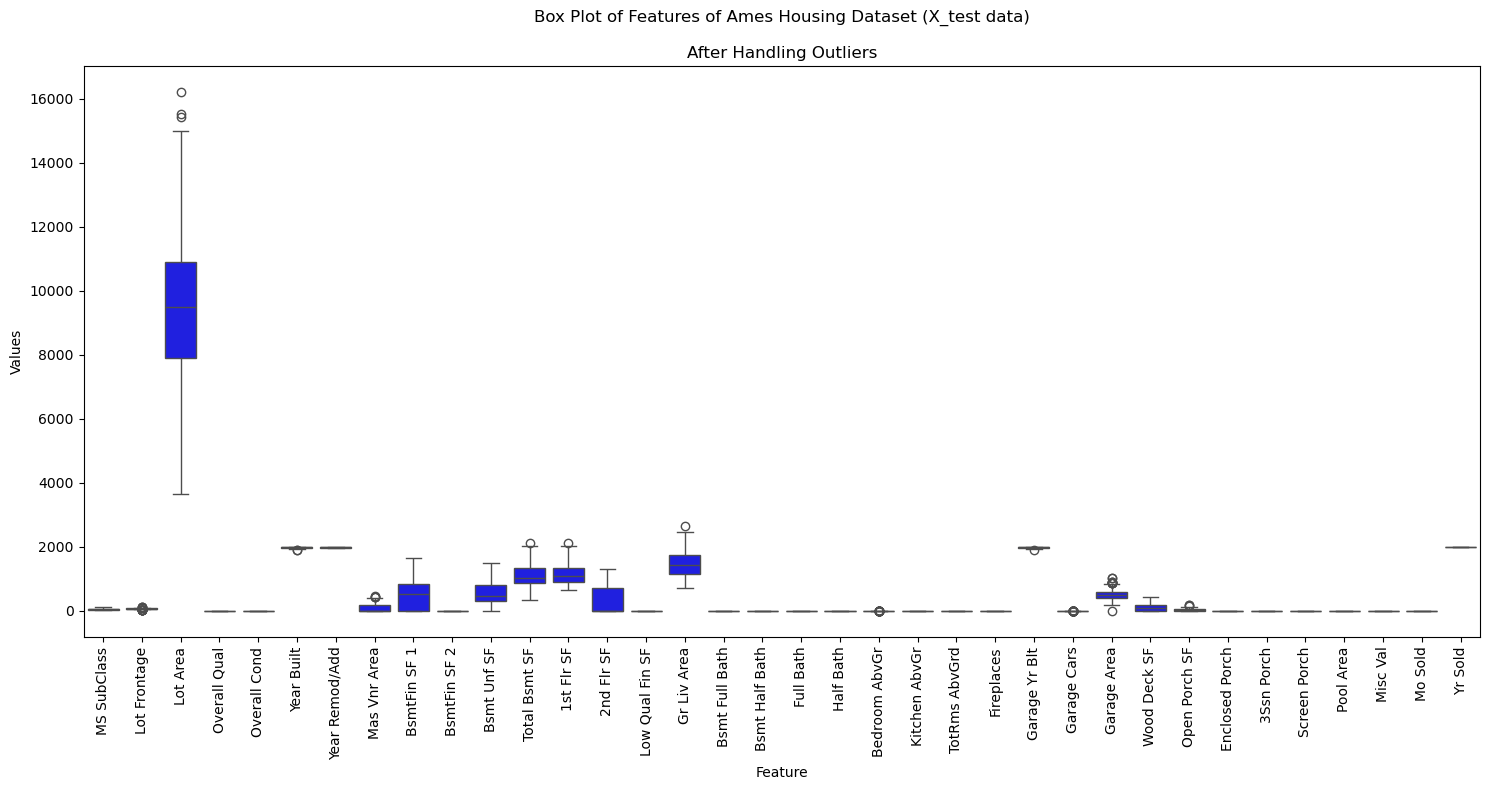

In [264]:
# Melt DataFrame
X_test_numeric_melted = pd.melt(X_test_numeric_inliers_df)

plt.figure(figsize=(15,8))
sns.boxplot(data=X_test_numeric_melted, x='variable', y='value', color='blue')
plt.xticks(rotation=90)
plt.xlabel('Feature')
plt.ylabel('Values')
plt.title('Box Plot of Features of Ames Housing Dataset (X_test data)\n\nAfter Handling Outliers')
plt.tight_layout()
plt.show()

**Scale Numerical data using StandardScaler()**

**We will be scaling for X_train_numeric_inliers_df, X_val_numeric_inliers_df, and X_test_numeric_inliers_df**

**Instatiate the StandardScaler(), ie. create an object for StandardScaler()**

## But first, we will base our dataset on 7 Features discovered in the downstream as Top (7) Feature Importance, since the Flask App expects the feature names to match those that were passed during fit (during scaling and model training):

In [269]:
X_train_numeric_inliers_df.columns

Index(['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold'],
      dtype='object')

**The 7 features are all contained in the X set of numeric_inliers_df. There is non in the categorical columns, as such, no need for OneHot Encoding**

In [271]:
X_train_7_features = pd.DataFrame(X_train_numeric_inliers_df, columns=['Overall Qual', 'Gr Liv Area', 'Garage Area', 'Year Built', 'BsmtFin SF 1', 'Garage Cars', 'Full Bath'], index=X_train.index)
X_val_7_features = pd.DataFrame(X_val_numeric_inliers_df, columns=['Overall Qual', 'Gr Liv Area', 'Garage Area', 'Year Built', 'BsmtFin SF 1', 'Garage Cars', 'Full Bath'], index=X_val.index)
X_test_7_features = pd.DataFrame(X_test_numeric_inliers_df, columns=['Overall Qual', 'Gr Liv Area', 'Garage Area', 'Year Built', 'BsmtFin SF 1', 'Garage Cars', 'Full Bath'], index=X_test.index)

In [272]:
print(X_train_7_features.shape)
print(X_val_7_features.shape)
print(X_test_7_features.shape)

(805, 7)
(166, 7)
(143, 7)


In [273]:
scaler_7_features = StandardScaler()

# Train and transform X_train_numeric 
X_train_scaled = scaler_7_features.fit_transform(X_train_7_features)

# Transform (scale) X_val_numeric_inliers_df using scaler_7_features
X_val_scaled = scaler_7_features.transform(X_val_7_features)

# Transform (scale) X_test_numeric_inliers_df using scaler_7_features
X_test_scaled = scaler_7_features.transform(X_test_7_features)

**Convert X_train_numeric_scaled and X_test_numeric_scaled back to dataframes**

**(Notice that we passed the original index (generated at train test split) to the converted dataframes, to avoid future mismatch)**
**Otherwise, these new datframes will have their index reset which we don't want.**

In [275]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_7_features.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val_7_features.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_7_features.columns, index=X_test.index)

print(X_train_scaled.head())
print('*****' * 15)

print(X_val_scaled.head())
print('*****' * 15)

print(X_test_scaled.head())

      Overall Qual  Gr Liv Area  Garage Area  Year Built  BsmtFin SF 1  \
1495     -0.257700    -0.131832    -0.229272   -0.330201     -0.367697   
2489     -0.257700    -0.597522     0.047117   -0.290463      0.157683   
358      -0.257700     0.163606    -0.394043    0.385095      0.384223   
2046     -1.023193    -0.792811    -1.292307   -1.760793     -0.309857   
299       1.273285    -0.650100     0.254409    0.186402     -0.878617   

      Garage Cars  Full Bath  
1495     0.211493  -1.268985  
2489     0.211493  -1.268985  
358      0.211493   0.718433  
2046    -1.231317  -1.268985  
299      0.211493   0.718433  
***************************************************************************
      Overall Qual  Gr Liv Area  Garage Area  Year Built  BsmtFin SF 1  \
2390      2.038778     1.603238     0.201257    0.822220      2.047123   
1731     -0.257700     0.111028    -0.229272    0.861959     -1.061777   
1100      1.273285     1.871135     1.875537    0.623527      0.516773 

In [276]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(805, 7)
(166, 7)
(143, 7)


**These are the descriptions of the Selected Features for Ames Housing dataset:**

* **Overall Qual- Rates the overall material and finish of the house**
* **Gr Liv Area- Above grade (ground) living area square feet**
* **Garage Area- Size of garage in square feet**
* **Year Built- Original construction date**
* **BsmtFin SF 1- Type 1 finished square feet of basement area**
* **Garage Cars- Size of garage in car capacity**
* **Full Bath- Full bathrooms above grade**

**Update:**

* **X_train**,

* **X_val**,

* **X_test** 

In [280]:
X_train = X_train_scaled
X_val = X_val_scaled
X_test = X_test_scaled

**Create model pipeline, and Train models**

**Evaluate Models with R square metric, and then with MSE and MAE**

In [282]:
model_pipeline = {
    'LinearRegression':
    Pipeline([
        ('model_1', LinearRegression())
    ]),
    'LinearSVR':
    Pipeline([
        ('model_2', LinearSVR(random_state=42))
    ]),
    'DecisionTreeRegressor':
    Pipeline([
        ('model_3', DecisionTreeRegressor(random_state=42))
    ]),
    'RandomForestRegressor':
    Pipeline([
        ('model_4', RandomForestRegressor(random_state=42)) 
    ]),
    'GBRegressor':
    Pipeline([
        ('model_5', GradientBoostingRegressor(loss='squared_error', random_state=42))
    ]),
    'XGBRegressor':
    Pipeline([
        ('model_6', xgboost.XGBRegressor(random_state=42))
    ]),
    'AdaBoostRegressor':
    Pipeline([
        ('model_6', AdaBoostRegressor(random_state=42))
    ])
}

for name, model in model_pipeline.items():
    model.fit(X_train, y_train)
    print(f'{name}_Score = {model.score(X_val, y_val)}')
    y_pred = model.predict(X_val)
    print(f'{name}_Mean Squared Error = {mean_squared_error(y_val, y_pred):.2f}')
    print(f'{name}_Mean Absolute Error = {mean_absolute_error(y_val, y_pred):.2f}')

LinearRegression_Score = 0.8825054566355602
LinearRegression_Mean Squared Error = 410015285.10
LinearRegression_Mean Absolute Error = 15319.67
LinearSVR_Score = -9.075156512338351
LinearSVR_Mean Squared Error = 35158808669.33
LinearSVR_Mean Absolute Error = 177958.30
DecisionTreeRegressor_Score = 0.7410215933124753
DecisionTreeRegressor_Mean Squared Error = 903744992.85
DecisionTreeRegressor_Mean Absolute Error = 19211.24
RandomForestRegressor_Score = 0.8987553393077593
RandomForestRegressor_Mean Squared Error = 353308819.54
RandomForestRegressor_Mean Absolute Error = 13831.76
GBRegressor_Score = 0.9161635833842035
GBRegressor_Mean Squared Error = 292560073.65
GBRegressor_Mean Absolute Error = 12851.44
XGBRegressor_Score = 0.8918169140815735
XGBRegressor_Mean Squared Error = 377521625.16
XGBRegressor_Mean Absolute Error = 14562.64
AdaBoostRegressor_Score = 0.8739802609002845
AdaBoostRegressor_Mean Squared Error = 439765267.18
AdaBoostRegressor_Mean Absolute Error = 16774.80


**Interpretations of Models Evaluation Metrices (R Square Score, MSE, and MAE)**

**Gradient Boosting has the lowest MSE and MAE among these models. Gradient Boosting Regressor with R squared score of 91.7% indicate a very good fit to our data. At 91.6%, the model explains a large proportion of the variance in the SalePrice.**

**Gradient Boosting Regressor is thus the most effective model based on these metrics**

### Hyperparameter Tuning: Using optuna library to perform Bayesian Optimization

In [285]:
# Define an Objective function that takes a trial object as input and returns the RMSE (root mean squared error)

def objective(trial):
    # Define hyperparameter space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }
    # Explicitly set public loss function
    g_b_r = GradientBoostingRegressor(loss='squared_error', **params)
    g_b_r.fit(X_train, y_train)
    y_pred = g_b_r.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    return rmse

# Optuna optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Train final model with best hyperparameters
best_params = study.best_params
optimal_gbr_mod = GradientBoostingRegressor(loss='squared_error', **best_params)
optimal_gbr_mod.fit(X_train, y_train)

# Evaluate
print(f'GradientBoostingRegressor_R2_Score: {optimal_gbr_mod.score(X_test, y_test):.2f}')
y_pred_optimal = optimal_gbr_mod.predict(X_test)
rmse_optimal = np.sqrt(mean_squared_error(y_test, y_pred_optimal))
print(f'Optimal RMSE: {rmse_optimal:.2f}')

[I 2025-07-07 19:48:25,648] A new study created in memory with name: no-name-02dc33a4-b487-4dfc-9492-043197f4bc71
[I 2025-07-07 19:48:25,994] Trial 0 finished with value: 17326.56055218905 and parameters: {'n_estimators': 154, 'learning_rate': 0.06903498765325541, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 10}. Best is trial 0 with value: 17326.56055218905.
[I 2025-07-07 19:48:27,087] Trial 1 finished with value: 20275.833484719 and parameters: {'n_estimators': 471, 'learning_rate': 0.20333873093670696, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 0 with value: 17326.56055218905.
[I 2025-07-07 19:48:27,746] Trial 2 finished with value: 20430.384046401112 and parameters: {'n_estimators': 201, 'learning_rate': 0.019570963577946406, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 0 with value: 17326.56055218905.
[I 2025-07-07 19:48:29,311] Trial 3 finished with value: 19409.19799280222 and parameters: {'n_esti

GradientBoostingRegressor_R2_Score: 0.92
Optimal RMSE: 19660.70


**1. Plot of Feature Importance**

In [287]:
def plot_feature_importance_type1(model, feature_names, top_n=5):
    '''
    Plots the top_n feature importances from a trained model with .feature_importances_ attribute. Type1 shows the plot on Jupiter notebook but
    is not saved as a file. Type2 does not show the plot on Jupiter notebook but saves it as file.

    Args:
        model: Trained model (must have .feature_importances_ attribute)
        feature_names: List of feature names (columns)
        top_n: Number of top features to plot
    '''
    
    
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Get feature impotances from model
    importance = model.feature_importances_
    
    # Create a Pandas Series of importance with feature_names as index
    importances_series = pd.Series(importance, index=feature_names)
    
    # Sort and get top n
    top_features = importances_series.sort_values(ascending=False).head(top_n)

    # Plot
    plt.figure(figsize=(8,6))
    sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', hue=top_features.index, legend=False)
    plt.title('Top Feature Importances')
    plt.xlabel('Importances Scores')
    plt.ylabel('Top Features')
    plt.grid(True, axis='x')
    plt.show()

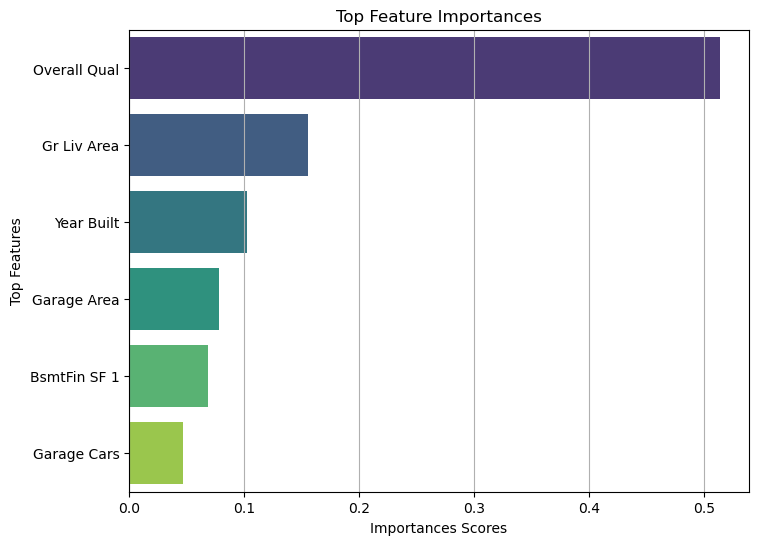

In [289]:
plot_feature_importance_type1(optimal_gbr_mod, X_train.columns, top_n=7)

**These are the descriptions of the Selected Features (Top Features) by the Gradient Boosting Regressor the for Ames Housing dataset:**

* **Overall Qual- Rates the overall material and finish of the house**

* **Gr Liv Area- Above grade (ground) living area square feet**

* **Garage Area- Size of garage in square feet**

* **Year Built- Original construction date**

* **BsmtFin SF 1- Type 1 finished square feet**

* **Garage Cars- Size of garage in car capacity**

## Model Interpretability/Explainability- with SHAP (SHapley Additive exPlanation)
**SHAP values are a common way of getting a consistent and objective explaination of how each feature impacts the model's prediction**

**They explain the predictions, not the actuals**

In [312]:
# Train Gradient Boosting Regressor (Already done above)

# Create a SHAP Explainer
explainer = shap.Explainer(optimal_gbr_mod)

# Calculate SHAP values
shap_values = explainer(X_test)

**Visualize Feature Importance and Contributions to predictions**

**Visualize first prediction explanation:**

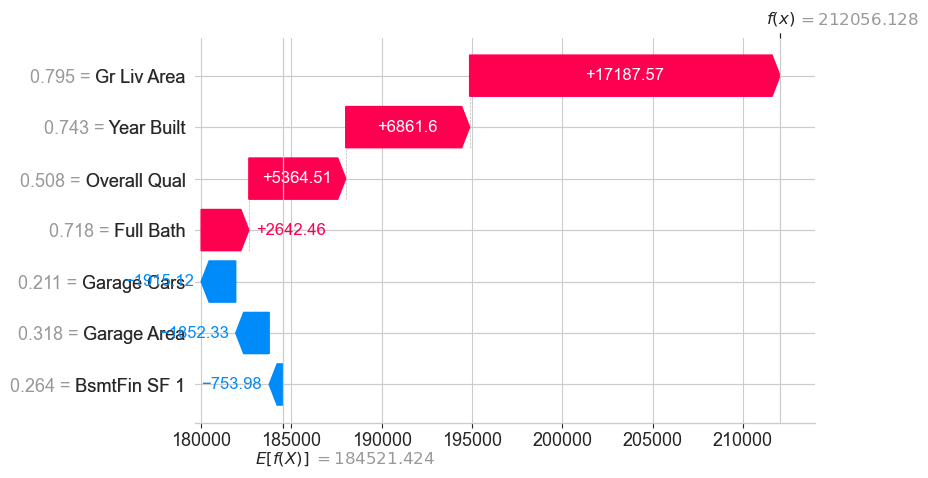

In [315]:
shap.plots.waterfall(shap_values[0])

**The waterfall plot shows how each feature in a given instance contributes to the final prediction**

**We will be using this plot in our sale price estimator app**

**Visualize last prediction explanation:**

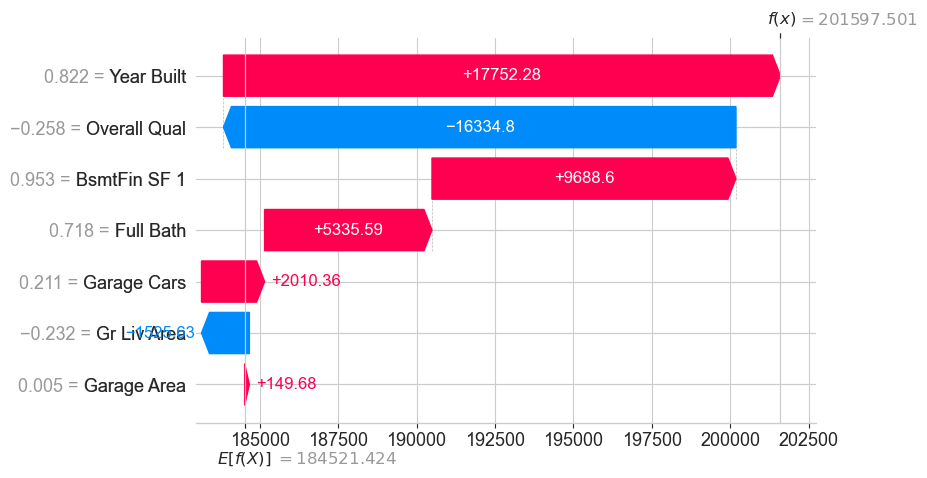

In [318]:
shap.plots.waterfall(shap_values[-1])
# Same as running shap.plots.waterfall(shap_values[142])

In [319]:
show = pd.DataFrame(Ames, columns=['Overall Qual', 'Gr Liv Area', 'Garage Area', 'Year Built', 'BsmtFin SF 1', 'Garage Cars', 'Full Bath'])
show.head()

,Overall Qual,Gr Liv Area,Garage Area,Year Built,BsmtFin SF 1,Garage Cars,Full Bath
0,6,1656,528.0,1960,639.0,2.0,1
1,5,896,730.0,1961,468.0,1.0,1
2,6,1329,312.0,1958,923.0,1.0,1
3,7,2110,522.0,1968,1065.0,2.0,2
4,5,1629,482.0,1997,791.0,2.0,2


In [320]:
show.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Overall Qual  2930 non-null   int64  
 1   Gr Liv Area   2930 non-null   int64  
 2   Garage Area   2929 non-null   float64
 3   Year Built    2930 non-null   int64  
 4   BsmtFin SF 1  2929 non-null   float64
 5   Garage Cars   2929 non-null   float64
 6   Full Bath     2930 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 160.4 KB


In [321]:
show.describe()

,Overall Qual,Gr Liv Area,Garage Area,Year Built,BsmtFin SF 1,Garage Cars,Full Bath
count,2930.000000,2930.000000,2929.000000,2930.000000,2929.000000,2929.000000,2930.000000
mean,6.094881,1499.690444,472.819734,1971.356314,442.629566,1.766815,1.566553
std,1.411026,505.508887,215.046549,30.245361,455.590839,0.760566,0.552941
min,1.000000,334.000000,0.000000,1872.000000,0.000000,0.000000,0.000000
25%,5.000000,1126.000000,320.000000,1954.000000,0.000000,1.000000,1.000000
50%,6.000000,1442.000000,480.000000,1973.000000,370.000000,2.000000,2.000000
75%,7.000000,1742.750000,576.000000,2001.000000,734.000000,2.000000,2.000000
max,10.000000,5642.000000,1488.000000,2010.000000,5644.000000,5.000000,4.000000


In [322]:
sio.dump(optimal_gbr_mod, './Ames_Sale_Price_Model.skops')

In [323]:
joblib.dump(scaler_7_features, './scaler.joblib')

['./scaler.joblib']